# Предсказание возраста посетителей сайтов


**Бизнес-задача**  
- Для лучшей эффективности изучить возрастную категорию аудиторию для таргетированной рекламы с помощью модели машинного обучения

---
**Цели**  
- Научить модель машинного обучения правильно распределять пользователей по возрастным категорям.

---
**Задачи**
- Разработать модель машинного обучения Многоклассовой классификации ('обучение с учителем')

---
**Целевая переменная**  
- Категория возраста (подробная информация ниже в описании данных)

---
**Важность проекта**
- Важно чтобы пользователи получали рекламу подходящую им, инаже дети могут получать рекомендации для взрослых, а взрослые могут получать рекламу детского контента.

---
**Критерии успешного проекта** 
- результат метрики по F1 с макро-усреднением БОЛЬШЕ 0.75.

---
**Дополнительные метрики**  
- precision и recall с макро-усреднением, матрица ошибок.

---
**Виды моделей которые будут использоваться**   
LogisticRegression с multi_class, OneVsRest, OneVsOne.

---
**Итоговая модель будет выбираться по результатам сравнения метрик по F1.**

---
**Описание исходных данных:**

**Таблица users**

Таблица **ds_s13_users.csv** содержит информацию о возрастной категории пользователя:  
**user_id** — уникальный идентификатор пользователя.  
ЦЕЛЕВАЯ ПЕРЕМЕННАЯ - **age_category** — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. Содержит следующие категории:  
**0:** младше 18;  
**1:** 18-25 лет;  
**2:** 26-40 лет;  
**3:** 41-55 лет;  
**4:** 56+ лет.

---
**Таблица visits**

Лог посещений сайтов **ds_s13_visits.csv**. Он предназначен для сбора и анализа информации об активности пользователей разных сайтов.

Признаки в датасете:  
**date** — дата посещения сайта.  
**daytime** — анонимизированное время посещения сайта. Категории: **утро**, **день**, **вечер**, **ночь**.  
**session_id** — уникальный идентификатор сессии.   
**user_id** — уникальный идентификатор пользователя.  
**website_category** — анонимизированная категория сайта. 

---
**Таблица ads_activity**

Активность взаимодействия пользователя с рекламными объявлениями — важный показатель, связанный с возрастом **ads_activity.csv**:   
**user_id** — уникальный идентификатор пользователя.  
**ads_activity** — характеристика CTR, выраженная одним из значений: **очень редко**, **редко**, **умеренно**, **часто**, **очень часто**.

---
**Таблица surf_depth**

В таблице **surf_depth.csv** содержится два признака:  
**user_id** — уникальный идентификатор пользователя.  
**surf_depth** — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории **поверхностно**, **средне**, **глубоко**.

---
**Таблица primary_device**

Таблица **primary_device.csv** содержит два признака:  
**user_id** — уникальный идентификатор пользователя.  
**primary_device** — информация о типе основного устройства пользователя для выхода в Интернет.

---
**Таблица cloud_usage**

Использование облачных технологий описано в файле **cloud_usage.csv**:  
**user_id** — уникальный идентификатор пользователя;  
**cloud_usage** — **True** означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.


## Подготовка среды и библиотек


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.feature_selection import (SelectKBest, chi2, f_classif, mutual_info_classif,
                                       RFE, RFECV, SelectFromModel,VarianceThreshold)
from sklearn.svm import SVC
from IPython.display import display
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
                             roc_auc_score, confusion_matrix,brier_score_loss, brier_score_loss,
                             roc_curve, precision_recall_curve,average_precision_score,log_loss, make_scorer)
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier


In [2]:
import joblib
!pip install category_encoders -q
from category_encoders import TargetEncoder

!pip install phik -q
from phik import phik_matrix

>Импортировали все необходимые библиотеки


In [3]:
RANDOM_STATE = 42

>Задали константу


In [4]:
ds_s13_users = pd.read_csv('/datasets/ds_s13_users.csv', sep = ',', decimal=".")
ds_s13_visits = pd.read_csv('/datasets/ds_s13_visits.csv', sep = ',', decimal=".")
ads_activity = pd.read_csv('/datasets/ads_activity.csv', sep = ',', decimal=".")
surf_depth = pd.read_csv('/datasets/surf_depth.csv', sep = ',', decimal=".")
primary_device = pd.read_csv('/datasets/primary_device.csv', sep = ',', decimal=".")
cloud_usage = pd.read_csv('/datasets/cloud_usage.csv', sep = ',', decimal=".")

>Подключили все таблицы


In [5]:
print(ds_s13_users.shape)
print(ds_s13_visits.shape)
print(ads_activity.shape)
print(surf_depth.shape)
print(primary_device.shape)
print(cloud_usage.shape)

(5913, 2)
(1065745, 5)
(5826, 2)
(5715, 2)
(5669, 2)
(5680, 2)


In [6]:
def prepare_features(users_df, visits_df, ads_df, surf_df, device_df, cloud_df):

    time_dist = visits_df.groupby(['user_id', 'daytime']).size().unstack(fill_value=0)
    time_dist.columns = [f'time_{col}' for col in time_dist.columns]
    

    time_pct = time_dist.div(time_dist.sum(axis=1), axis=0).fillna(0)
    time_pct.columns = [f'time_{col}_pct' for col in time_pct.columns]
    
    primary_time = visits_df.groupby('user_id')['daytime'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
    ).rename('daytime_mode')
    
    site_dist = visits_df.groupby(['user_id', 'website_category']).size().unstack(fill_value=0)
    site_dist.columns = [f'site_{col}' for col in site_dist.columns]
    

    site_pct = site_dist.div(site_dist.sum(axis=1), axis=0).fillna(0)
    site_pct.columns = [f'site_{col}_pct' for col in site_pct.columns]
    
    primary_site = visits_df.groupby('user_id')['website_category'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
    ).rename('website_category_mode')
    
    base_stats = visits_df.groupby('user_id').agg(
        total_sessions=('session_id', 'count'),
        total_days=('date', 'nunique')
    )
    base_stats['avg_sessions_per_day'] = base_stats['total_sessions'] / base_stats['total_days']
    

    base_stats['site_diversity'] = visits_df.groupby('user_id')['website_category'].nunique()
    base_stats['site_diversity_idx'] = base_stats['site_diversity'] / base_stats['total_sessions']
    
    visits_profile = pd.concat([
        time_dist, time_pct,  
        site_dist, site_pct,
        primary_time.to_frame(), 
        primary_site.to_frame(),
        base_stats
    ], axis=1).fillna(0).reset_index()
    

    result = users_df.merge(visits_profile, on='user_id', how='left') \
                     .merge(ads_df, on='user_id', how='left') \
                     .merge(surf_df, on='user_id', how='left') \
                     .merge(device_df, on='user_id', how='left') \
                     .merge(cloud_df, on='user_id', how='left')
    

    if 'ночь' in result.columns and 'total_sessions' in result.columns:
        result['night_ratio'] = result['ночь'] / result['total_sessions']
    
    return result

>По ТЗ требуется чтобы в разных выборках в будущем не попадались одинаковые пользователи из таблицы с "Сессиями" делаем некий "Профиль" и из миллиона строк делаем статистику по каждому пользователю


In [7]:
df = prepare_features(ds_s13_users, ds_s13_visits, ads_activity, surf_depth, primary_device, cloud_usage)

display(df.head())

,user_id,age_category,time_вечер,time_день,time_ночь,time_утро,time_time_вечер_pct,time_time_день_pct,time_time_ночь_pct,time_time_утро_pct,...,website_category_mode,total_sessions,total_days,avg_sessions_per_day,site_diversity,site_diversity_idx,ads_activity,surf_depth,primary_device,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,64,69,15,44,0.333333,0.359375,0.078125,0.229167,...,Category 05,192,14,13.714286,19,0.098958,NaN,глубоко,смартфон,False
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,57,48,13,26,0.395833,0.333333,0.090278,0.180556,...,Category 03,144,14,10.285714,19,0.131944,умеренно,средне,смартфон,False
2,678b-614cd47d854b9d591db2-000b2e50,0,38,31,13,20,0.372549,0.303922,0.127451,0.196078,...,Category 12,102,14,7.285714,17,0.166667,умеренно,средне,смартфон,False
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,66,111,18,58,0.260870,0.438735,0.071146,0.229249,...,Category 18,253,14,18.071429,19,0.075099,редко,поверхностно,смартфон,True
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,51,41,9,21,0.418033,0.336066,0.073770,0.172131,...,Category 12,122,14,8.714286,19,0.155738,очень редко,поверхностно,смартфон,True


>В итоге получаем Датафрейм с данными по каждому пользователю с которым можно переходить к Исследовательскому анализу данных


## Исследовательский анализ данных


In [8]:
display(df.head())

,user_id,age_category,time_вечер,time_день,time_ночь,time_утро,time_time_вечер_pct,time_time_день_pct,time_time_ночь_pct,time_time_утро_pct,...,website_category_mode,total_sessions,total_days,avg_sessions_per_day,site_diversity,site_diversity_idx,ads_activity,surf_depth,primary_device,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,64,69,15,44,0.333333,0.359375,0.078125,0.229167,...,Category 05,192,14,13.714286,19,0.098958,NaN,глубоко,смартфон,False
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,57,48,13,26,0.395833,0.333333,0.090278,0.180556,...,Category 03,144,14,10.285714,19,0.131944,умеренно,средне,смартфон,False
2,678b-614cd47d854b9d591db2-000b2e50,0,38,31,13,20,0.372549,0.303922,0.127451,0.196078,...,Category 12,102,14,7.285714,17,0.166667,умеренно,средне,смартфон,False
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,66,111,18,58,0.260870,0.438735,0.071146,0.229249,...,Category 18,253,14,18.071429,19,0.075099,редко,поверхностно,смартфон,True
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,51,41,9,21,0.418033,0.336066,0.073770,0.172131,...,Category 12,122,14,8.714286,19,0.155738,очень редко,поверхностно,смартфон,True


In [9]:
df['cloud_usage'] = df['cloud_usage'].astype(str)

In [10]:
print(df['age_category'].value_counts())
print(round(df['age_category'].value_counts(normalize=True),2))

4    1879
2    1531
3    1307
0     893
1     536
Name: age_category, dtype: int64
4    0.31
2    0.25
3    0.21
0    0.15
1    0.09
Name: age_category, dtype: float64


>Наблюдаем дисбаланс данных   
самый популярный класс 4(56+) - 31%  
наименьший класс 1(18-25) - 9%
разница более чем в 3 разма между ними


In [11]:
print(df.isna().sum())

user_id                 0
age_category            0
time_вечер              0
time_день               0
time_ночь               0
                     ... 
site_diversity_idx      0
ads_activity          238
surf_depth            117
primary_device        164
cloud_usage             0
Length: 61, dtype: int64


>В 4 категориальных признаках присутствовали пропуски. При создании пайплайнов на этапе предобработки заполним пропуски 'unknown'


In [12]:
print(df.duplicated().sum())
print(df['user_id'].duplicated().sum())

320
320


In [13]:
df = df.drop_duplicates()

>Дубликаты ни к чему - удаляю


In [14]:
print(df.nunique())

user_id               5826
age_category             5
time_вечер             185
time_день              183
time_ночь               62
                      ... 
site_diversity_idx     777
ads_activity             5
surf_depth               3
primary_device           4
cloud_usage              3
Length: 61, dtype: int64


>**Стратегия работы с категориальными признаками:**  
В будущем при предобработке призкаки с малым количеством категорий обработаю через OneHotEncoder, признаки где более 10 категорий через TargetEncoder


In [15]:
df.describe()

,age_category,time_вечер,time_день,time_ночь,time_утро,time_time_вечер_pct,time_time_день_pct,time_time_ночь_pct,time_time_утро_pct,site_Category 01,...,site_site_Category 16_pct,site_site_Category 17_pct,site_site_Category 18_pct,site_site_Category 19_pct,site_site_Category 20_pct,total_sessions,total_days,avg_sessions_per_day,site_diversity,site_diversity_idx
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,...,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,2.440439,65.584964,66.778579,14.262788,36.302781,0.358154,0.364979,0.078124,0.198743,9.129591,...,0.043195,0.046993,0.048015,0.051967,0.047882,182.929111,13.998627,13.067160,18.472880,0.115163
std,1.381287,29.118112,28.890714,7.335664,16.455000,0.049283,0.045456,0.024757,0.038321,7.142945,...,0.028470,0.029178,0.031817,0.028808,0.029157,76.390669,0.037034,5.455714,0.767831,0.038430
min,0.000000,22.000000,22.000000,0.000000,5.000000,0.215517,0.217822,0.000000,0.049020,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,13.000000,7.142857,14.000000,0.022274
25%,2.000000,44.000000,46.000000,9.000000,25.000000,0.323651,0.335106,0.060811,0.172414,4.000000,...,0.021173,0.025424,0.024631,0.030870,0.026524,126.000000,14.000000,9.000000,18.000000,0.085859
50%,3.000000,60.000000,61.000000,13.000000,33.000000,0.357694,0.365269,0.076271,0.196532,8.000000,...,0.040604,0.045137,0.044444,0.050000,0.045455,169.000000,14.000000,12.071429,19.000000,0.109827
75%,4.000000,79.000000,80.000000,18.000000,44.000000,0.392014,0.395512,0.093567,0.223847,13.000000,...,0.060297,0.065185,0.067568,0.070000,0.066938,217.000000,14.000000,15.500000,19.000000,0.145038
max,4.000000,305.000000,308.000000,69.000000,196.000000,0.532468,0.536364,0.198020,0.356436,79.000000,...,0.160000,0.185185,0.206349,0.188119,0.182171,853.000000,14.000000,60.928571,19.000000,0.190000


<Figure size 1440x1800 with 0 Axes>

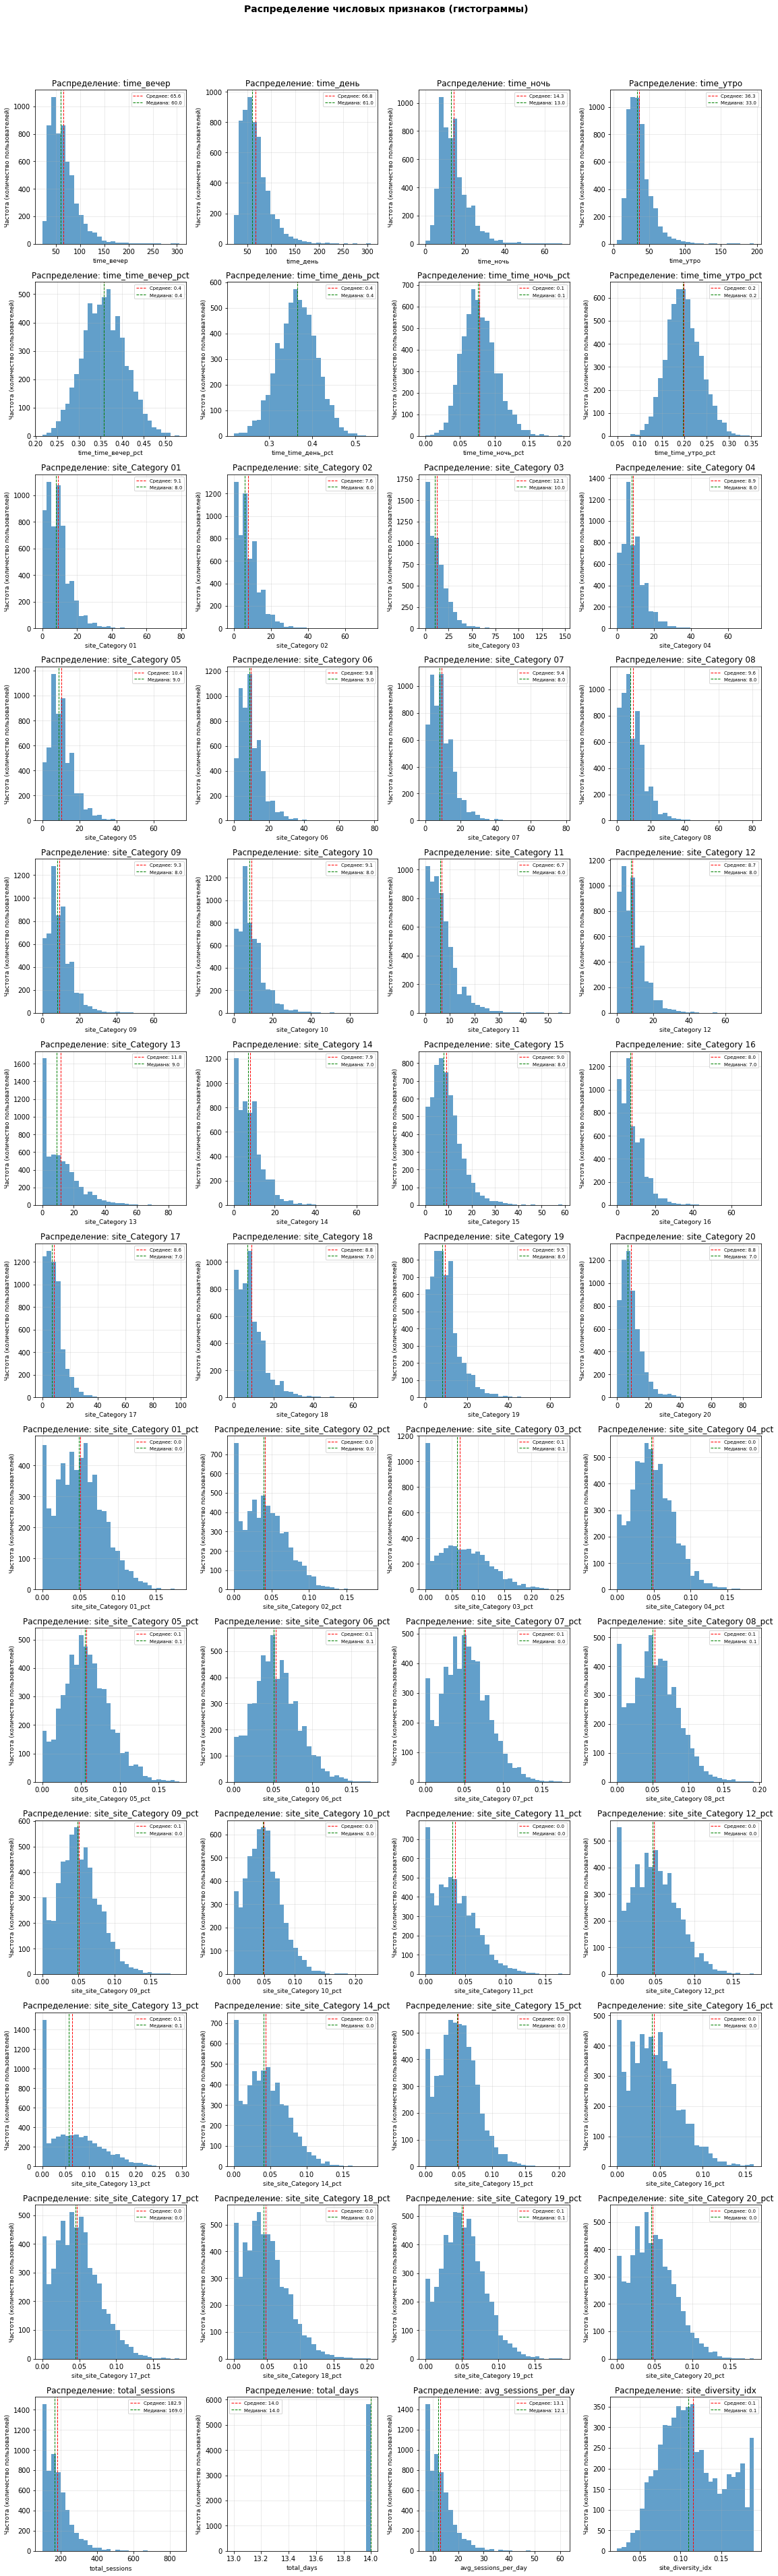

In [16]:
plt.figure(figsize = (20, 25))


num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col not in ['age_category', 'site_diversity']]

n_cols = len(num_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, alpha=0.7)
    ax.set_title(f'Распределение: {col}')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Частота (количество пользователей)', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Среднее: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=1, label=f'Медиана: {median_val:.1f}')
    ax.legend(fontsize=7)


plt.suptitle('Распределение числовых признаков (гистограммы)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

>Времена суток распределяются почти одинокаво, все 4 графика со смещением влево

>Все категории тоже распределяются почти одинаково со смещением влево (основное количество от 0 - 20)

>Количество сессий - больше пользователей с менее 200 сессий

>Количество дней почти все данные со значением 14


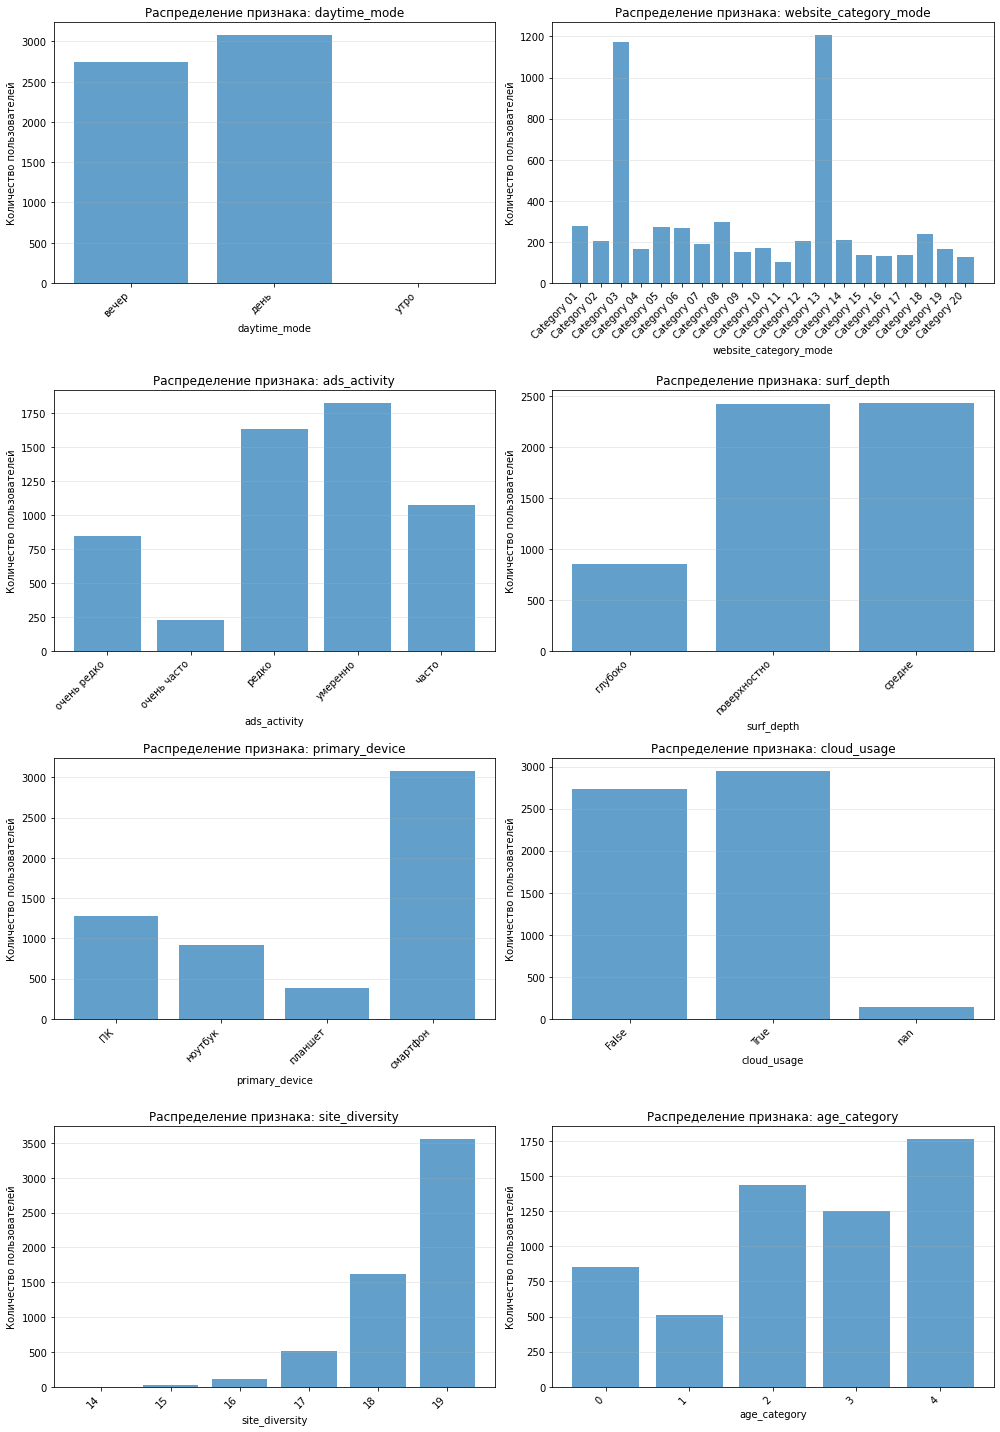

In [17]:
additional_cols = ['site_diversity', 'age_category']
additional_cols = [col for col in additional_cols if col in df.columns]

cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = [col for col in cat_cols if col != 'user_id']


all_cat_cols = list(cat_cols) + additional_cols

n_cols = len(all_cat_cols)
n_rows = (n_cols + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(all_cat_cols):
    ax = axes[i]
    
    value_counts = df[col].value_counts().sort_index()
    bars = ax.bar(range(len(value_counts)), value_counts.values, alpha=0.7)
    ax.set_title(f'Распределение признака: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Количество пользователей')
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

>Мода по времени суток - два явных лидера День: 3000+ , Вечер: 2500+ 

>У категорий два очень явных лидера Категория 13(примерно 1200) и Категория 03(почти 1200), а остальные категории распределены равномерно   

>Взаимодействие с рекламой "Умерено"(примерно 1750) - самое популярное, а самый редкий класс "Очень часто" (менее 250)

>Глубина перехода: две почти одинаковые категории "Средне" и "Поверхностно" близко к 2500, а "Глубоко" менее 1000

>Приоритетный вид устройства: Лидирующая категория "Смартфон" (3000+), отстающая категория "Планешет" манее (500)

>Использование облачных сервисов: "Используюущие" преобладает на числом "Неиспользующие"


<Figure size 720x288 with 0 Axes>

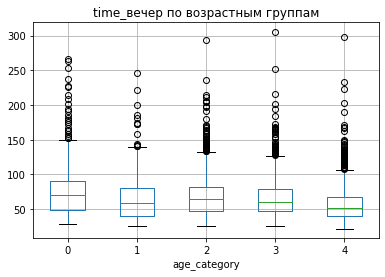

<Figure size 720x288 with 0 Axes>

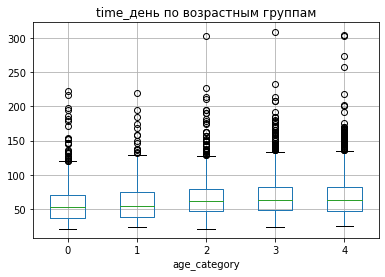

<Figure size 720x288 with 0 Axes>

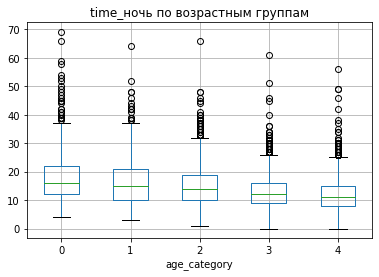

<Figure size 720x288 with 0 Axes>

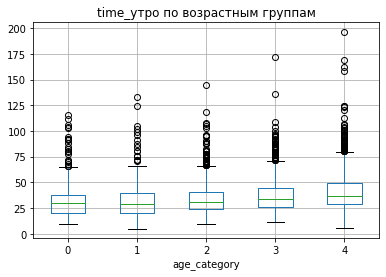

<Figure size 720x288 with 0 Axes>

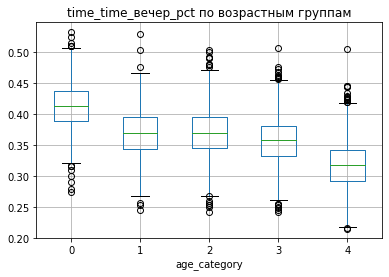

<Figure size 720x288 with 0 Axes>

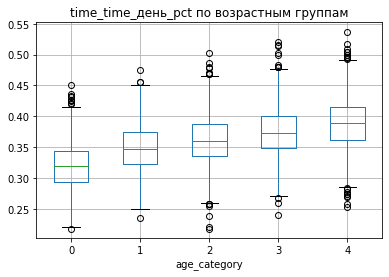

<Figure size 720x288 with 0 Axes>

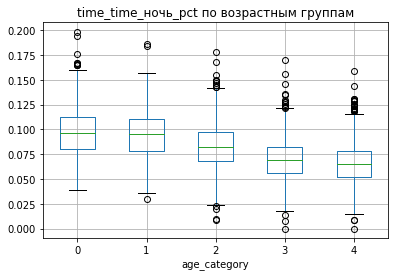

<Figure size 720x288 with 0 Axes>

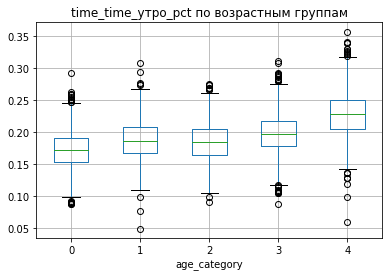

<Figure size 720x288 with 0 Axes>

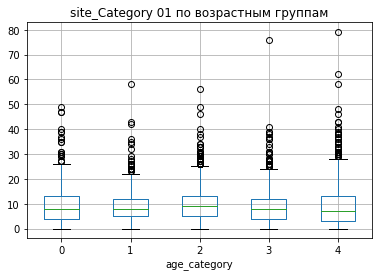

<Figure size 720x288 with 0 Axes>

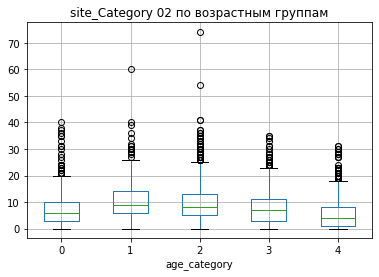

<Figure size 720x288 with 0 Axes>

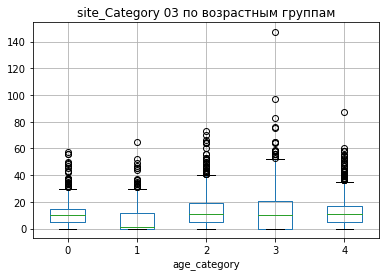

<Figure size 720x288 with 0 Axes>

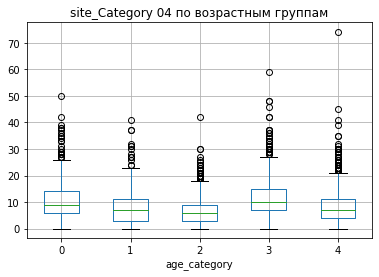

<Figure size 720x288 with 0 Axes>

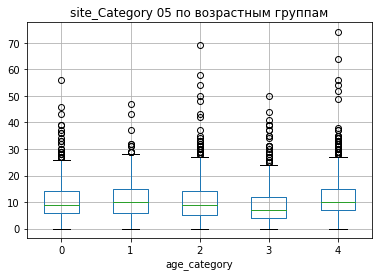

<Figure size 720x288 with 0 Axes>

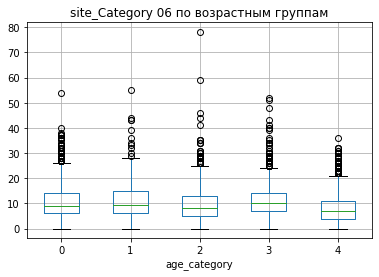

<Figure size 720x288 with 0 Axes>

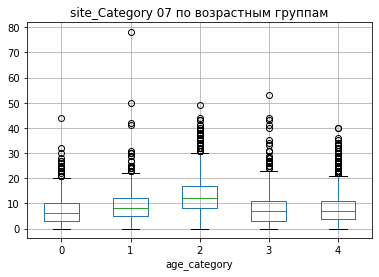

<Figure size 720x288 with 0 Axes>

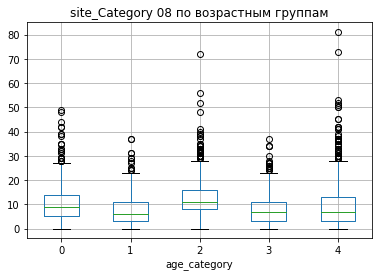

<Figure size 720x288 with 0 Axes>

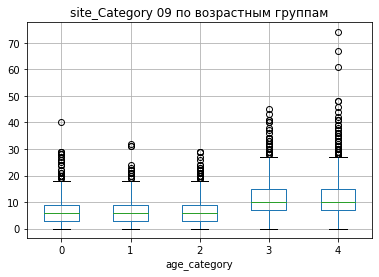

<Figure size 720x288 with 0 Axes>

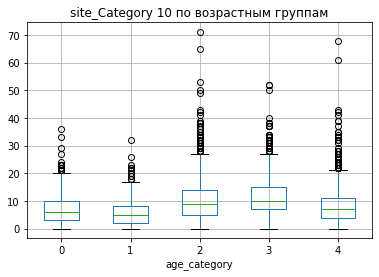

<Figure size 720x288 with 0 Axes>

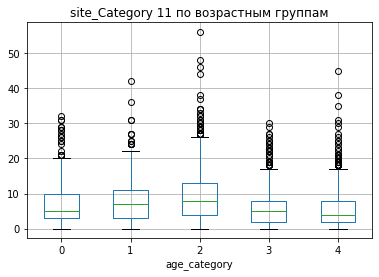

<Figure size 720x288 with 0 Axes>

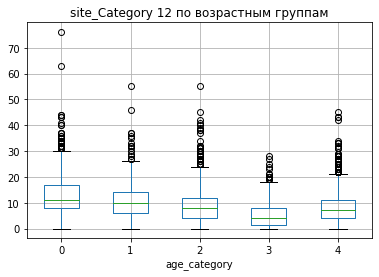

<Figure size 720x288 with 0 Axes>

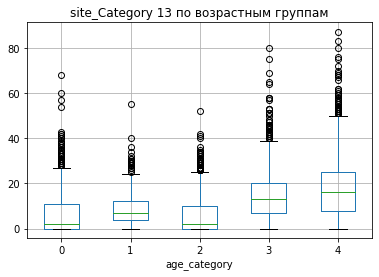

<Figure size 720x288 with 0 Axes>

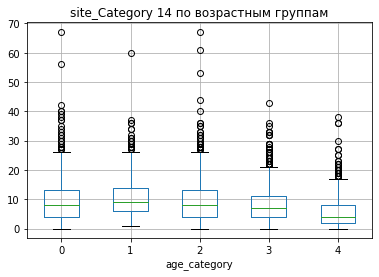

<Figure size 720x288 with 0 Axes>

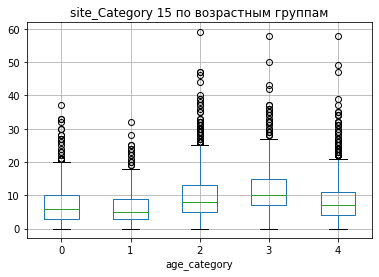

<Figure size 720x288 with 0 Axes>

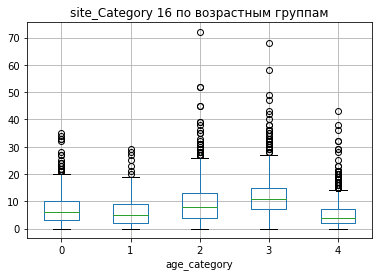

<Figure size 720x288 with 0 Axes>

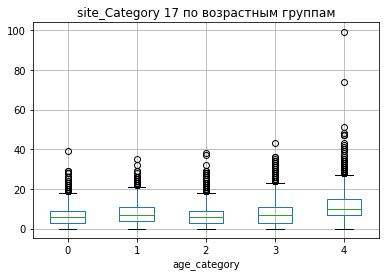

<Figure size 720x288 with 0 Axes>

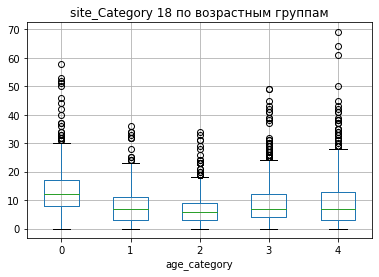

<Figure size 720x288 with 0 Axes>

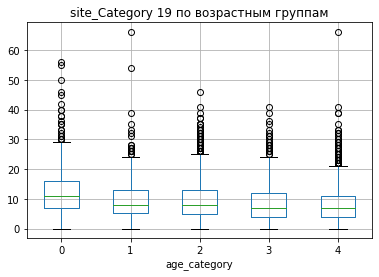

<Figure size 720x288 with 0 Axes>

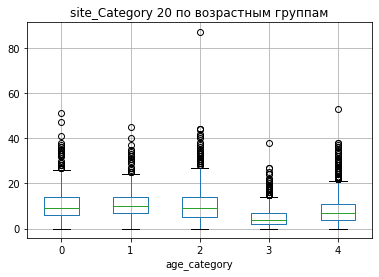

<Figure size 720x288 with 0 Axes>

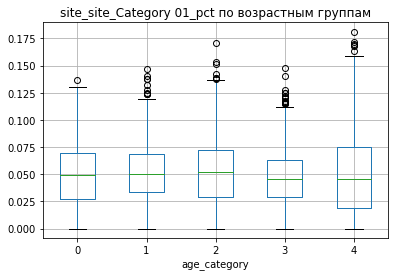

<Figure size 720x288 with 0 Axes>

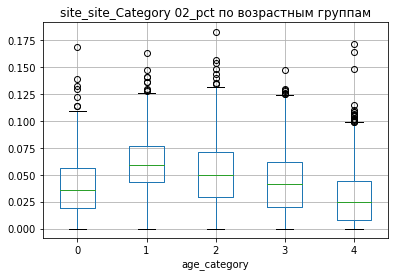

<Figure size 720x288 with 0 Axes>

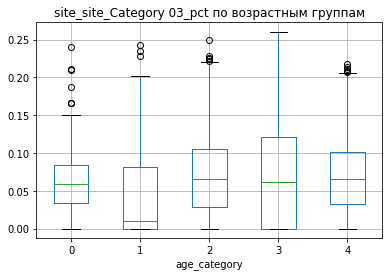

<Figure size 720x288 with 0 Axes>

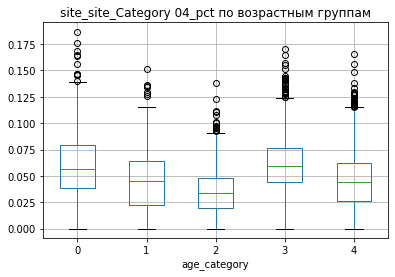

<Figure size 720x288 with 0 Axes>

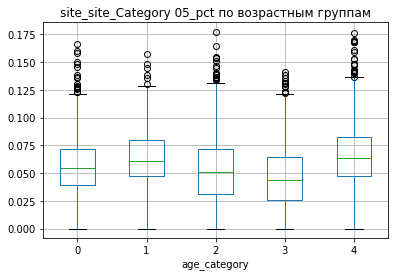

<Figure size 720x288 with 0 Axes>

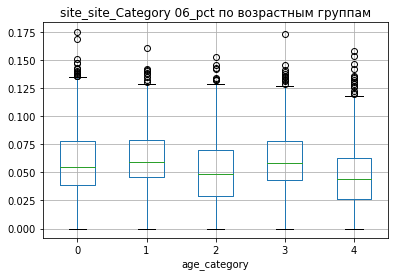

<Figure size 720x288 with 0 Axes>

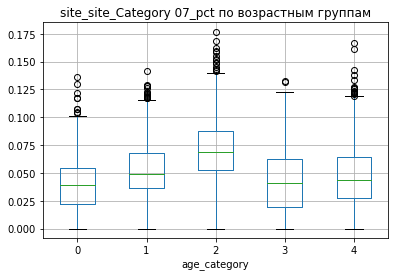

<Figure size 720x288 with 0 Axes>

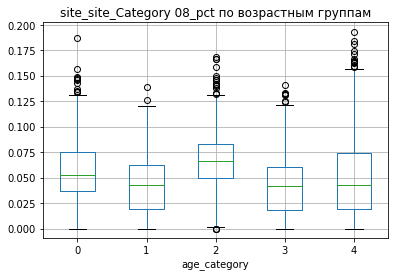

<Figure size 720x288 with 0 Axes>

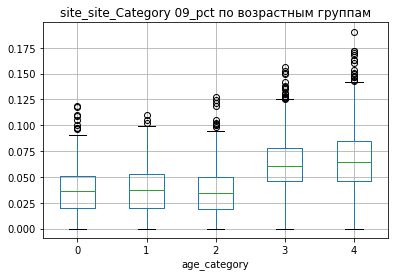

<Figure size 720x288 with 0 Axes>

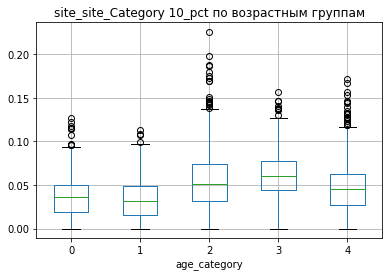

<Figure size 720x288 with 0 Axes>

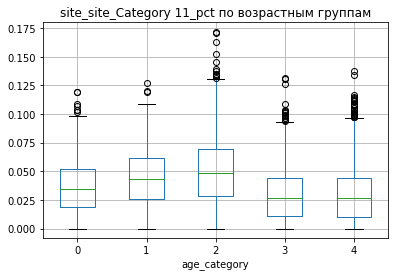

<Figure size 720x288 with 0 Axes>

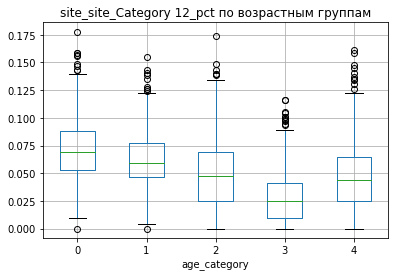

<Figure size 720x288 with 0 Axes>

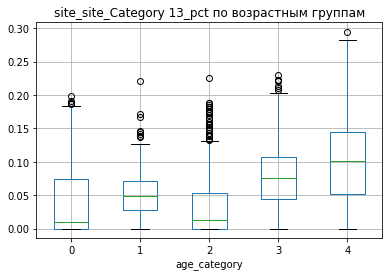

<Figure size 720x288 with 0 Axes>

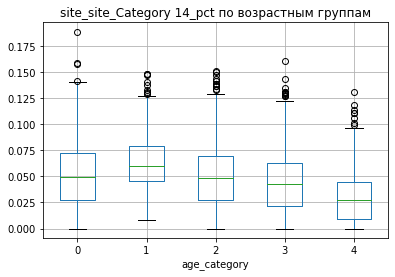

<Figure size 720x288 with 0 Axes>

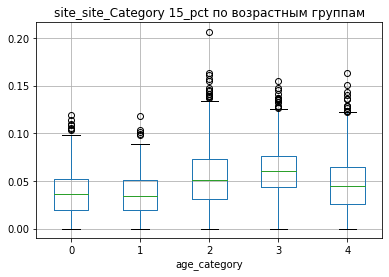

<Figure size 720x288 with 0 Axes>

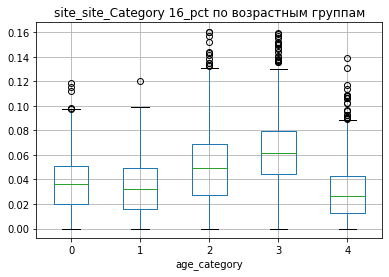

<Figure size 720x288 with 0 Axes>

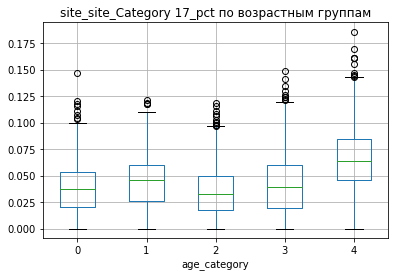

<Figure size 720x288 with 0 Axes>

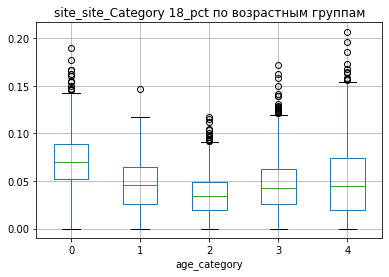

<Figure size 720x288 with 0 Axes>

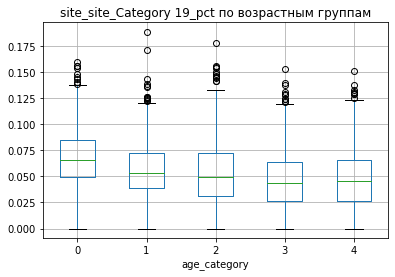

<Figure size 720x288 with 0 Axes>

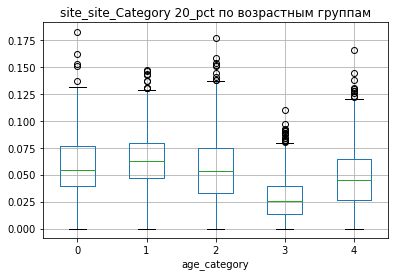

<Figure size 720x288 with 0 Axes>

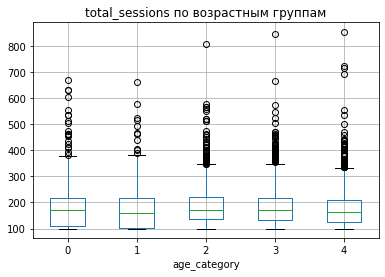

<Figure size 720x288 with 0 Axes>

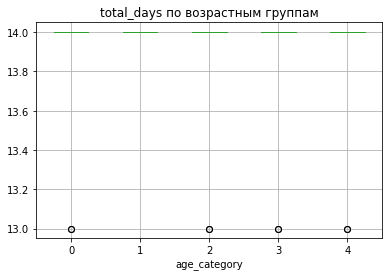

<Figure size 720x288 with 0 Axes>

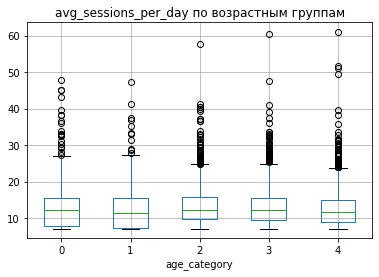

<Figure size 720x288 with 0 Axes>

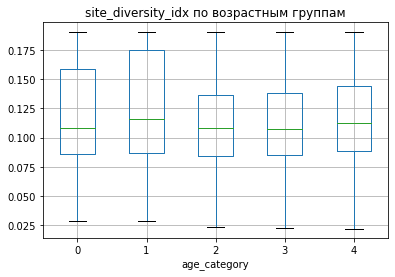

In [18]:
num_cols = [col for col in num_cols if col != 'age_category']

for col in num_cols: 
    plt.figure(figsize=(10, 4))
    df.boxplot(column=col, by='age_category')
    plt.title(f'{col} по возрастным группам')
    plt.suptitle('')
    plt.show()

>Диаграммы размахов по целевой переменной и всем числовым признакам:  
Все признаки давольно хорошо распределенны, нет каких то прям аномальных выбросов, все они выглядят реалистично, удалять их не нужно.   
Так же все ящики выглядят хорошо, нет таких которые "Скукожились"


In [19]:
df = df.drop(columns=['user_id'])

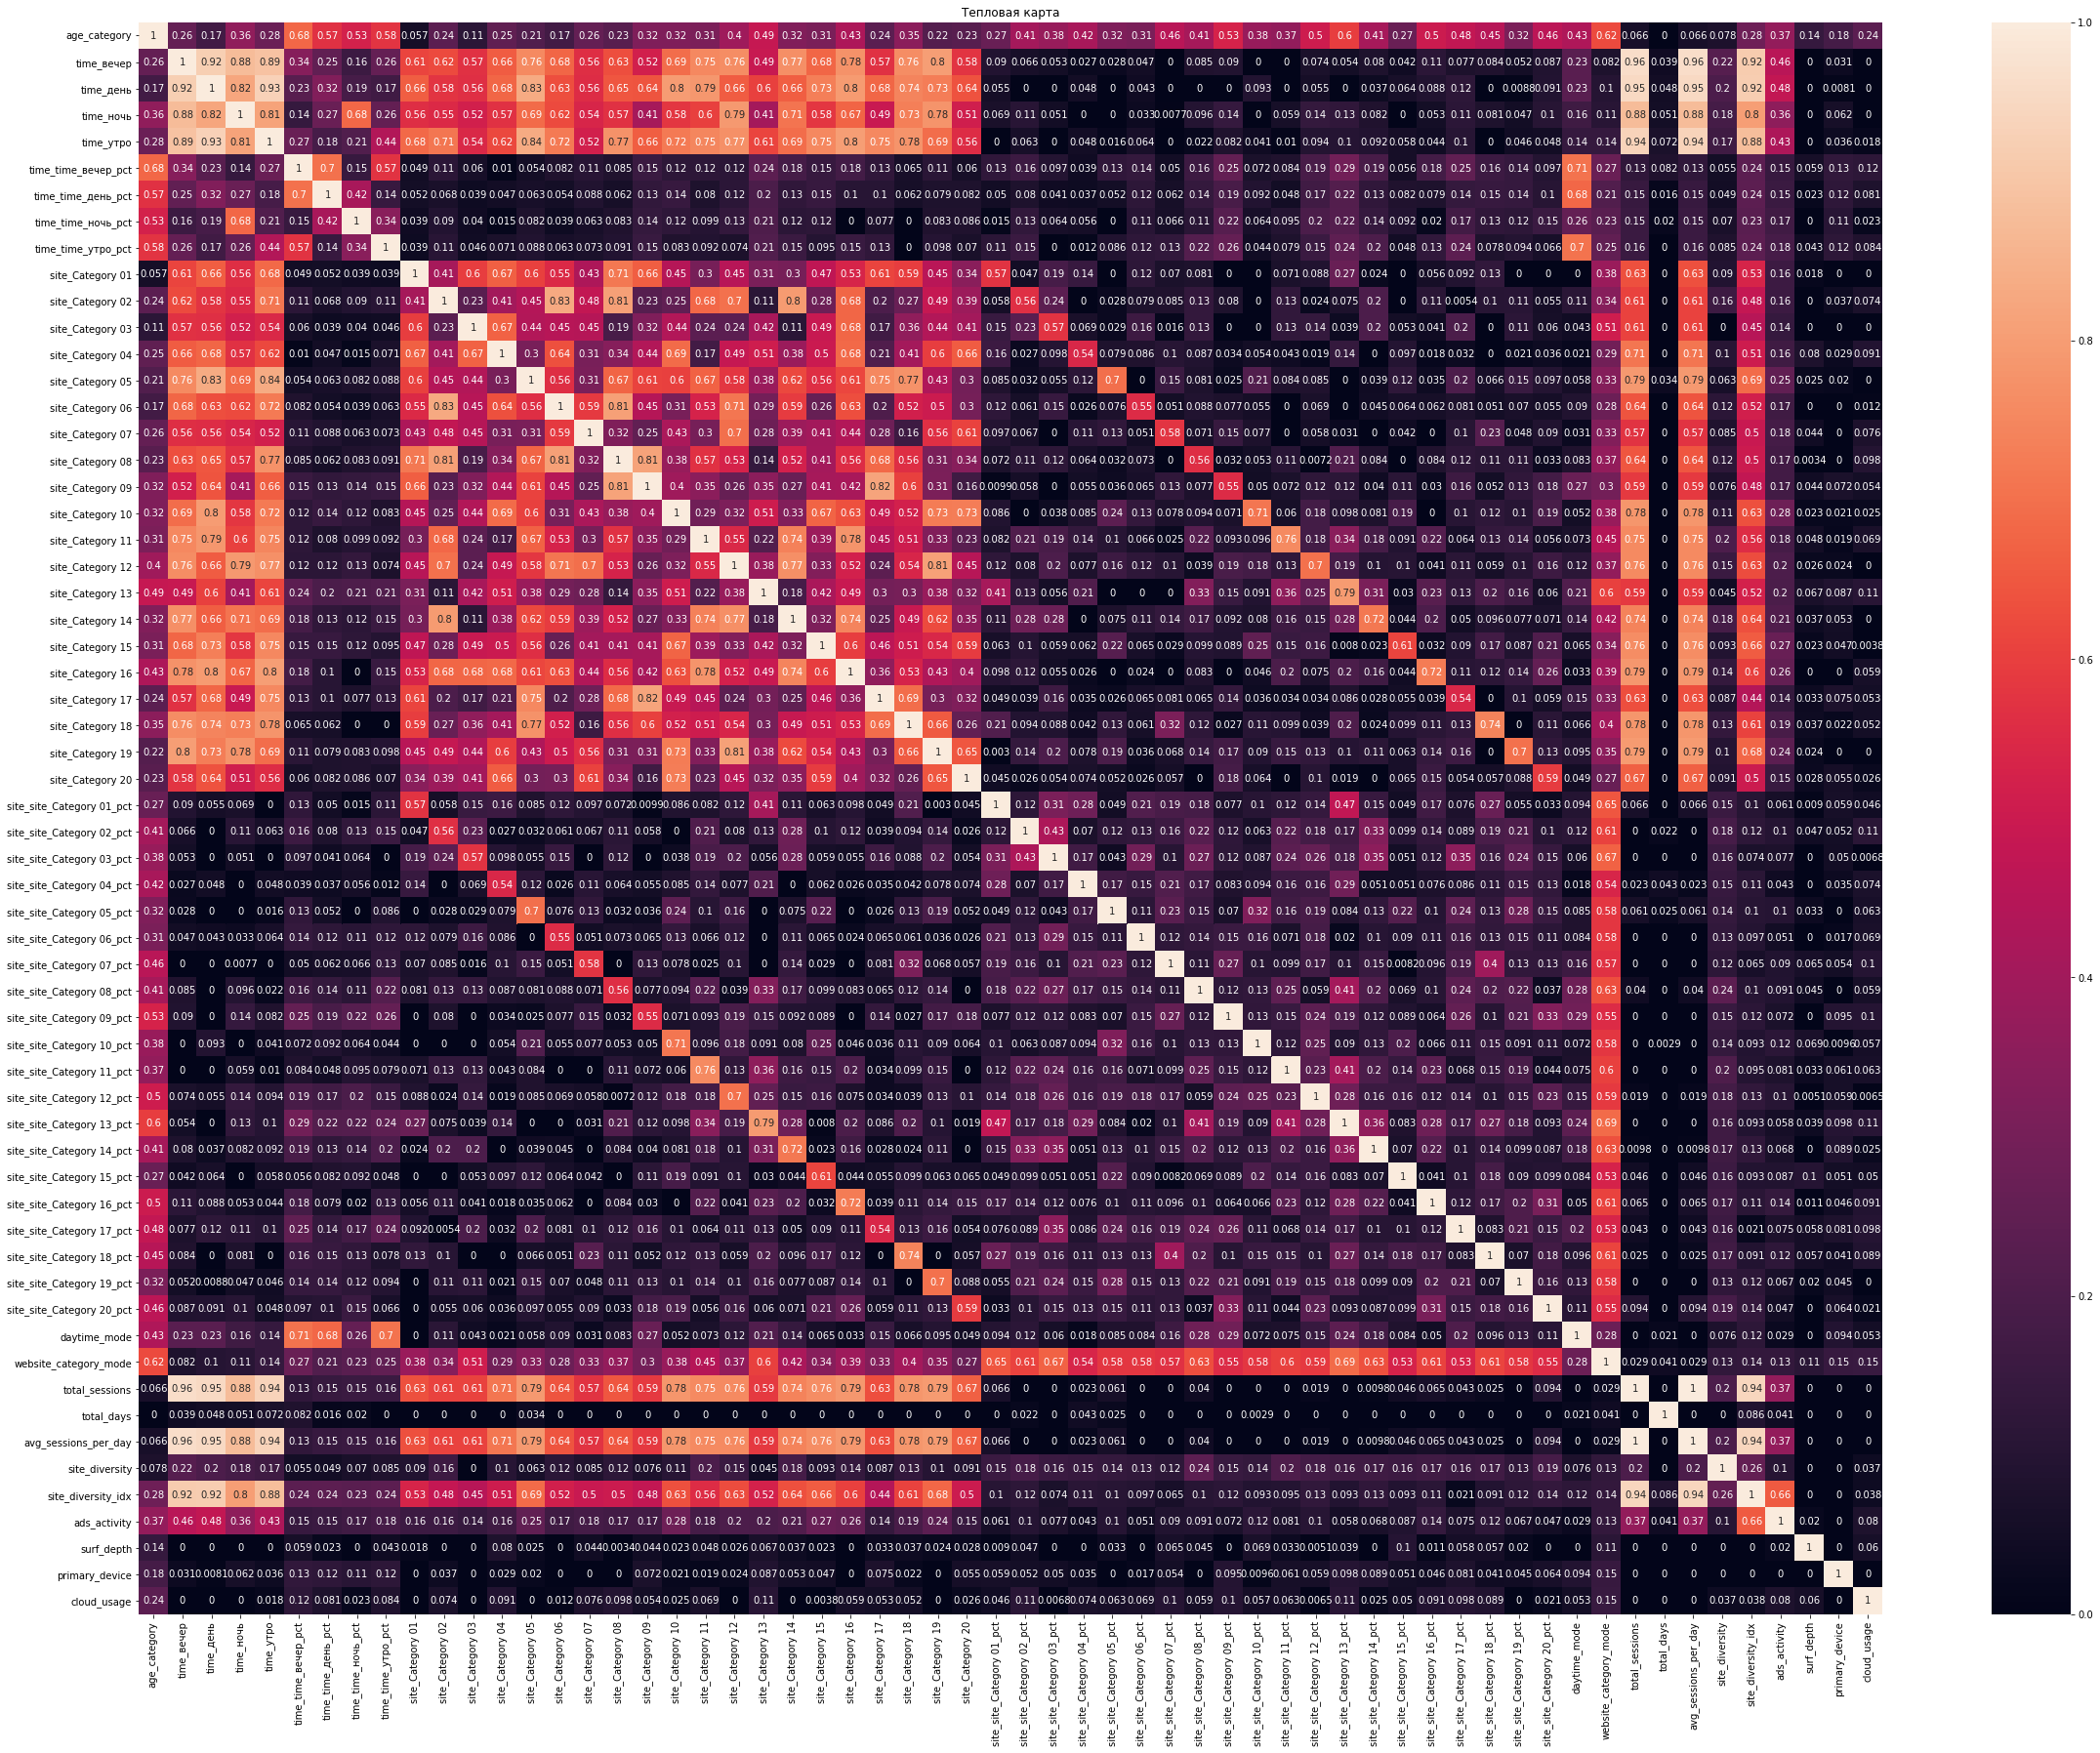

In [20]:
df_num_features = df.select_dtypes(include=['int64', 'float64']).columns

df_cor = phik_matrix(df, interval_cols=df_num_features)
plt.figure(figsize=(40,30))
sns.heatmap(df_cor, annot=True)
plt.title('Тепловая карта')
plt.show()

In [21]:
df = df.drop(columns=['total_days'])

> Присутствуют признаки с мультиколлинеарностью, но убирать их пока не буду потому что в дальнейшем буду использовать L1 которая решает проблему мультиколинераности.


Итоги EDA (исследовательского анализа данных)

**1. Общая информация о данных**
- **Размер датафрейма:** 5826 строк, 35 колонок
- **Типы данных:** 28 числовых (int64), 7 категориальных (object)
- **Целевая переменная:** age_category (5 классов)

**2. Анализ целевой переменной**
- **Сильный дисбаланс классов:**
  - Класс 4 (56+): **31%** (1879)
  - Класс 2 (26-40): **25%** (1531)  
  - Класс 3 (41-55): **21%** (1307)
  - Класс 0 (младше 18): **15%** (893)
  - Класс 1 (18-25): **9%** (536) **проблемный класс**
- Разница между самым большим и самым маленьким классом более чем в 3 раза

**3. Пропуски**
- Пропуски обнаружены в 3 категориальных признаках:
  - ads_activity: 238 пропусков
  - surf_depth: 117 пропусков  
  - primary_device: 164 пропуска
- **Решение:** заполнить константой 'unknown' на этапе предобработки

**4. Дубликаты**
- Обнаружено **320 полных дубликатов** (по всем колонкам)
- Дубликаты удалены, так как они:
  - Искажают веса в линейных моделях
  - Смещают границы классов
  - Увеличивают время обучения

**5. Распределение числовых признаков (гистограммы)**

**Времена суток** (вечер, день, ночь, утро):
- Все распределения имеют **смещение влево** (правый хвост)
- Большинство пользователей имеют 40-80 сессий в день/вечер
- Ночных сессий значительно меньше (в основном до 20)

**Категории сайтов** (Category 01 - Category 20):
- Однотипное распределение со смещением влево
- Основное количество значений **от 0 до 20**
- Есть выбросы до 150 сессий на некоторых категориях

**Производные признаки:**
- total_sessions: большинство пользователей имеют **100-300 сессий**
- total_days: практически все значения **14 дней** (константа)
- avg_sessions_per_day: в основном **7-15 сессий в день**

**6. Распределение категориальных признаков**

**daytime_mode** (любимое время):
- **День:** ~3000 пользователей
- **Вечер:** ~2500 пользователей
- Утро/ночь: значительно меньше

**website_category_mode** (любимая категория):
- Явные лидеры: **Category 13** (примерно 1200), **Category 03** (примерно1200)
- Остальные категории распределены равномерно (по 200-400)

**ads_activity** (взаимодействие с рекламой):
- **Умеренно:** ~1750
- Редко/очень редко: ~1000-1200
- Часто: ~600
- **Очень часто:** менее 250 редкий класс

**surf_depth** (глубина просмотра):
- **Средне:** ~2500
- **Поверхностно:** ~2400
- **Глубоко:** менее 1000

**primary_device** (основное устройство):
- **Смартфон:** ~3000+ (доминирует)
- Планшет: менее 500 (редко)

**cloud_usage** (облачные сервисы):
- Использующие преобладают над неиспользующими

**7. Анализ выбросов (boxplot по возрастным группам)**

- Все числовые признаки имеют **выбросы**, но они выглядят **реалистично**
- **Решение:** выбросы не удаляем, так как они отражают реальное поведение пользователей

**8. Ключевые выводы для моделирования**

1. **Дисбаланс классов** требует использования class_weight='balanced' или аналогичных техник
2. **Пропуски** будут заполнены константой 'unknown' (чтобы модель могла выучить, что отсутствие данных — тоже признак)
3. **Признаки с малым числом уникальных значений** (daytime_mode: 3, surf_depth: 3, primary_device: 4) — подходят для OneHotEncoder
4. **Признаки с большим числом уникальных значений** (website_category_mode: 20, категории сайтов) — потребуют TargetEncoder
5. **total_days — практически константа** (14 дней у всех) — можно удалить
6. **Выбросы оставляем** — они не аномальные, а отражают реальную вариативность поведения


## Предобработка данных


In [22]:
X = df.drop(columns='age_category')
y = df['age_category']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, shuffle=True, random_state = RANDOM_STATE, stratify=y)
num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object','category']).columns

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(4660, 58)
(1166, 58)
4    0.303219
2    0.246996
3    0.215236
0    0.146352
1    0.088197
Name: age_category, dtype: float64
4    0.302744
2    0.246998
3    0.215266
0    0.146655
1    0.088336
Name: age_category, dtype: float64


>Разделил датафрейм на 2 выборки.  
Разделили признаки на числовые и категориальные.
Информация распределена равномерно.


In [23]:
cat_features_oh = []
cat_features_te = []

for i in cat_features:
    counter = X_train[i].nunique()
    if counter <= 10:
        cat_features_oh.append(i)
    else:
        cat_features_te.append(i)
        
print(cat_features_oh)
print(cat_features_te)

['daytime_mode', 'ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']
['website_category_mode']


>Разделили категориальные признаки для OneHotEncoder и TargetEncoder


In [24]:
def sqrt_num(X):
    return np.sqrt(np.abs(X))

num_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('sqrt', FunctionTransformer(sqrt_num))
])

cat_oh_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='error', sparse=False, drop='first'))
])
cat_te_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', TargetEncoder(smoothing=20.0))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat_oh', cat_oh_pipeline, cat_features_oh),
    ('cat_te', cat_te_pipeline, cat_features_te)
])

>**Создал препроцессор включающий в себя**:  
**Обработку числовых признаков** - Стандартизировали и извлекли корень (сглаживание выбросов)  
**Обработка категориальных признаков** - заболнили пропуски константой и закодировали с помощью OneHotEncoder и TargetEncoder  
**Трансформер со всеми пайплайнами**


## Обучение и оценка базовой модели


In [25]:
scoring = {
    'Precision': make_scorer(precision_score, average='macro'),
    'Recall': make_scorer(recall_score, average='macro'),
    'F1-score': make_scorer(f1_score, average='macro')
}

dummy = DummyClassifier(strategy='prior')

stf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, multi_class='multinomial')

ovr = OneVsRestClassifier(SVC(kernel='linear'))

ovo = ovo = OneVsOneClassifier(SVC(kernel='linear'))

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', logreg)
])

ovr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',ovr)
])

ovo_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', ovo)
])

In [26]:
scores_dummy = cross_validate(dummy, X_train, y_train, cv=stf, scoring=scoring)
scores_logreg = cross_validate(logreg_pipeline, X_train, y_train, cv=stf, scoring=scoring)
scores_ovr = cross_validate(ovr_pipeline, X_train, y_train, cv=stf, scoring=scoring)
scores_ovo = cross_validate(ovo_pipeline, X_train, y_train, cv=stf, scoring=scoring)

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Pr

In [27]:
print('Dummy')
print('Precision:', round(scores_dummy['test_Precision'].mean(),3))
print('Recall:', round(scores_dummy['test_Recall'].mean(),3))
print('F1_score:', round(scores_dummy['test_F1-score'].mean(),3))
print('')
 
print('Logreg_multi_class')
print('Precision:', round(scores_logreg['test_Precision'].mean(),3))
print('Recall:', round(scores_logreg['test_Recall'].mean(),3))
print('F1_score:', round(scores_logreg['test_F1-score'].mean(),3))
print('')
 
print('OvR')
print('Precision:', round(scores_ovr['test_Precision'].mean(),3))
print('Recall:', round(scores_ovr['test_Recall'].mean(),3))
print('F1_score:', round(scores_ovr['test_F1-score'].mean(),3))
print('')
 
print('OvO')
print('Precision:', round(scores_ovo['test_Precision'].mean(),3))
print('Recall:', round(scores_ovo['test_Recall'].mean(),3))
print('F1_score:', round(scores_ovo['test_F1-score'].mean(),3))
print('')
 

Dummy
Precision: 0.061
Recall: 0.2
F1_score: 0.093

Logreg_multi_class
Precision: 0.574
Recall: 0.552
F1_score: 0.556

OvR
Precision: 0.497
Recall: 0.489
F1_score: 0.463

OvO
Precision: 0.567
Recall: 0.549
F1_score: 0.552



>**Обучил базовую модель Dummy, результаты метрик:**  
Precision: 0.061  
Recall: 0.2  
F1_score: 0.093  

>Logreg_multi_class показал лучший результат по F1, но остальные метрки не сильно отстают. Самое главное что все остальные модели показывают результаты превышающие результаты Dummy.


## Создание и отбор признаков


In [28]:
# selector_var = VarianceThreshold(threshold=0.01)
# selector_kbest = SelectKBest(score_func=mutual_info_classif, k=30)
# selector_rfecv = RFECV(
#     estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
#     step=2,
#     cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
#     scoring='f1_macro',
#     n_jobs=-1
# )

# pipeline_var = Pipeline([
#     ('preprocessor', preprocessor),
#     ('selector', selector_var)
# ])

# pipeline_kbest = Pipeline([
#     ('preprocessor', preprocessor),
#     ('selector', selector_kbest)
# ])

# pipeline_rfecv = Pipeline([
#     ('preprocessor', preprocessor),
#     ('selector', selector_rfecv)
# ])


# X_train_base = preprocessor.fit_transform(X_train, y_train)
# X_train_var = pipeline_var.fit_transform(X_train, y_train)
# X_train_kbest = pipeline_kbest.fit_transform(X_train, y_train)
# X_train_rfecv = pipeline_rfecv.fit_transform(X_train, y_train)

# print('Размер после препроцессора:', X_train_base.shape[1])
# print('Размер после VarianceThreshold:', X_train_var.shape[1])
# print('Размер после SelectKBest:', X_train_kbest.shape[1])
# print('Размер после RFECV:', X_train_rfecv.shape[1])

>Размер после препроцессора: 41  
Размер после VarianceThreshold: 40  
Размер после SelectKBest: 30  
Размер после RFECV: 35  

Я перепробывал использовать отбор признаков, но получается так что с со всеми методами итоговые метрики ниже чем с без использования отбора


## Подбор гиперпараметров моделей


In [29]:
# logreg_pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('selector', selector_var),
#     ('classifier', logreg)
# ])

# param_grid_logreg = {
#     'classifier__solver': ['saga'],
#     'classifier__penalty': ['l1', 'l2'],
#     'classifier__C': [0.1, 1, 10],
#     'classifier__class_weight': ['balanced'],
#     'classifier__max_iter': [1000, 2000]
# }

# grid_search = GridSearchCV(
#     logreg_pipeline,
#     param_grid_logreg,
#     cv=stf,
#     scoring='f1_macro',
#     n_jobs=-1
# )
# grid_search.fit(X_train, y_train)

# print("Лучшие параметры:")
# print(grid_search.best_params_)
# print(f"Лучший F1-macro: {grid_search.best_score_:.4f}")

In [30]:
ovr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',ovr)
])

param_grid_ovr = {
    'classifier__estimator__kernel': ['rbf'],
    'classifier__estimator__C': [0.5, 1, 5, 10],  
    'classifier__estimator__gamma': ['scale', 'auto', 0.1, 0.05],  
    'classifier__estimator__class_weight': ['balanced']
}

grid_search_ovr = GridSearchCV(
    ovr_pipeline,
    param_grid_ovr,
    cv=stf,
    scoring='f1_macro',
    n_jobs=-1
)


grid_search_ovr.fit(X_train, y_train)

print("Лучшие параметры OvR:", grid_search_ovr.best_params_)
print("Лучший F1 OvR:", grid_search_ovr.best_score_)

Лучшие параметры OvR: {'classifier__estimator__C': 5, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__gamma': 'scale', 'classifier__estimator__kernel': 'rbf'}
Лучший F1 OvR: 0.688052619190369


In [31]:
# ovo_pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', ovo)
# ])

# param_grid_ovo = {
#     'classifier__estimator__C': [0.1, 1, 10],
#     'classifier__estimator__kernel': ['linear', 'rbf'],
#     'classifier__estimator__gamma': ['scale', 'auto'],
#     'classifier__estimator__class_weight': ['balanced']
# }
# grid_search_ovo = GridSearchCV(
#     ovo_pipeline,
#     param_grid_ovo,
#     cv=stf,
#     scoring='f1_macro',
#     n_jobs=-1
# )


# grid_search_ovo.fit(X_train, y_train)

# print("Лучшие параметры OvO:", grid_search_ovo.best_params_)
# print("Лучший F1 OvO:", grid_search_ovo.best_score_)

>Получаем 3 лучших модели.  
Из них лучшей по метрике F1 становится OvR, будем работать дальше с ней.  
(остальные две модели закоментировал чтобы не нагружать ядро при перезапуске его)


Accuracy на тестовом наборе: 0.7246998284734134
Precision на тестовом наборе: 0.7052597363688264
Recall на тестовом наборе: 0.7011156107701284
F1 на тестовом наборе: 0.703003183047262
Матрица ошибок:
[[126   8  19   9   9]
 [ 13  60  13  13   4]
 [ 11  15 197  42  23]
 [ 10  14  26 168  33]
 [  6   3  22  28 294]]


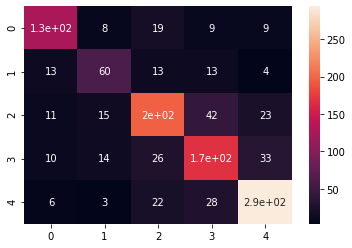

In [32]:
best_model = grid_search_ovr.best_estimator_
predictions = best_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy на тестовом наборе:", accuracy)

precision = precision_score(y_test, predictions, average='macro')
print("Precision на тестовом наборе:", precision)

recall = recall_score(y_test, predictions, average='macro')
print("Recall на тестовом наборе:", recall)


f1 = f1_score(y_test, predictions, average='macro')
print("F1 на тестовом наборе:", f1)

cm = confusion_matrix(y_test, predictions)
print("Матрица ошибок:")
print(cm)
sns.heatmap(cm, annot=True)
plt.show()

>На тесте получен F1 = 0.70 - Хороший результат


## Подготовка артефактов модели для внедрения


In [33]:
with open('data_preparation.pkl', 'wb') as f:
    pickle.dump(prepare_features, f)
print("Функция сохранена")

best_model = grid_search_ovr.best_estimator_
joblib.dump(best_model, 'age_prediction_model.pkl')
print("Модель сохранена")

Функция сохранена
Модель сохранена


In [34]:
with open('data_preparation.pkl', 'rb') as f:
    loaded_func = pickle.load(f)

loaded_model = joblib.load('age_prediction_model.pkl')


original_pred = grid_search_ovr.predict(X_test)
loaded_pred = loaded_model.predict(X_test)
print(f"Предсказания модели совпадают: {np.array_equal(original_pred, loaded_pred)}")


df_test = loaded_func(ds_s13_users, ds_s13_visits, ads_activity, surf_depth, primary_device, cloud_usage)
print(f"Функция работает, форма данных: {df_test.shape}")

Предсказания модели совпадают: True
Функция работает, форма данных: (6146, 61)


>Модель корректно сохраняется и корректно загружается и работает.


## Выводы о результатах работы


**Основные этапы работы:**

1. **Данные** — разработана функция prepare_features, объединяющая 6 таблиц. Созданы новые признаки: распределение активности по времени суток и категориям сайтов (абсолютные и относительные), моды, базовая статистика, индексы разнообразия.

2. **Анализ** — выявлен дисбаланс классов (класс 1 — 9%, класс 4 — 31%), пропуски заполнены 'unknown', удалены дубликаты и неинформативный признак total_days. Проведен графический анализ всех признаков.

3. **Предобработка** — создан пайплайн: числовые признаки (стандартизация + корень), категориальные (OneHotEncoder с drop='first', TargetEncoder со сглаживанием 20.0).

4. **Модели** — сравнены Dummy, LogisticRegression, OvR (SVC), OvO (SVC). Лучший результат показал OvR с SVC.

5. **Отбор признаков** — RFECV сократил признаки с 41 до 35, но использование отбора ухудшало метрики, поэтому финальная модель обучается без него.

6. **Гиперпараметры** — GridSearchCV для OvR (SVC rbf) подобрал параметры: C=5, gamma='scale', kernel='rbf', class_weight='balanced'.

7. **Тестирование** — на тестовой выборке получены метрики: Precision=0.70, Recall=0.70, **F1=0.70**.

8. **Артефакты** — сохранены функция подготовки (data_preparation.pkl) и модель (age_prediction_model.pkl), загрузка проверена.


**Анализ качества модели:**

Модель значительно превосходит базовый уровень (DummyClassifier с F1=0.093).  
Высокое качество модели (F1 = 0.70) достигнуто за счет:  
создания новых признаков (проценты, индексы разнообразия)  
перехода на SVC с rbf-ядром (учет нелинейных зависимостей)  
использования class_weight='balanced' для борьбы с дисбалансом  
Наилучшие результаты достигнуты для классов 2 (26-40 лет) и 4 (56+).  
Класс 1 (18-25 лет) остается проблемным из-за сильного дисбаланса, но качество предсказаний значительно улучшилось.  

**Рекомендации по внедрению:**  

Модель достигла значения F1=0.70, что является высоким результатом для данного датасета. Модель может быть рекомендована к внедрению для определения возрастных категорий пользователей с целью таргетирования рекламы.
